In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("lec_act_7_simulation.ipynb")

# Simulation

In this lecture activity, you will simulate a ball accelerating through the air using basic Newtonian physics. The lab and homework also involve simulations, but of a more complex quarter and half car.

The lecture activity involves:

- Full 2D - position and velocity of a point in space
- Integrate velocity as well as position
- Acceleration is a function of an inclined plane

Slides: https://docs.google.com/presentation/d/1jDIVbp7EkyqVJJCpXnkg9KQl6stHF9WohauL1Lnr3YM/edit?usp=sharing


In [2]:
# The usual imports
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import polynomial
import matplotlib.animation as animation
# Enable animations to work
%matplotlib widget

## One time step
TODO: Calculate new position and velocity, given position, velocity, and acceleration

In [3]:
def simulate_one_step(x, y, vx, vy, ax, ay, delta_t):
    
    """ TODO simulate one step forward using Euler integration 
       (x1 = x0 + delta_t * v0),
       (v1 = v0 + delta_t * a0)
       @param x, y - position
       @param vx, vy - velocity
       @param ax, ay - acceleration
       @return x_next, y_next, vx_next, vy_next"""
    x_next = x + delta_t * vx
    y_next = y + delta_t * vy

    vx_next = vx + delta_t * ax
    vy_next = vy + delta_t * ay

    return x_next, y_next, vx_next, vy_next

In [4]:
# Time step
delta_t = 0.1

x = 1
y = 2
vx = 0.1
vy = 0.3
ax = 0.001
ay = 1.0
xnew, ynew, vxnew, vynew = simulate_one_step(x, y, vx, vy, ax, ay, delta_t)

# Testing one of these here
assert np.isclose(xnew, x + vx * delta_t)

In [5]:
grader.check("compute_one_step")

compute_one_step results: All test cases passed!

# Simulate

Note that you could use either the number of time steps OR total time for the last parameter

Timesteps is a bit safer because at least you know it will only go for so many time steps...

In this activity we'll just loop over n time steps; we'll do something "smarter" in the lab

See Iterate n times in Lab 5 ODE systems for an example of how to store values in an array during a simulation time step


TODO: Fill in ret_pose_all

In [15]:
def simulate_n_time_steps(x, y, vx, vy, ax, ay, delta_t=0.1, n_time_steps=100):
    """ Call simulate_one_step multiple times and store it in a numpy array
    @param starting_state - the starting position, velocity, acceleration
    @param delta_t - the time step to use. Define a default t value that you've determined works well
    @param n_time_steps - how many time steps to take. Again, default to a reasonable number
    @return position values as a 2xtimesteps numpy array
    """
    # TODO
    #   Allocate an array to put all the x,y values in
    #   Loop n_time_steps
    #     Store the current x,y values in the array
    #     Call simulate_one_step with the current x,y,vx,vy values
    #     Save the returned x,y,vx,vy values as the "new" current x,y,vx,vy values
    #   return the array
    simulation_data = np.zeros((4, n_time_steps)) # n time step rows and 4 values for collums
    for n in range(n_time_steps) :
        simulation_data.T[n] = x, y, vx, vy
        x,y,vx,vy = simulate_one_step(x,y,vx,vy, ax, ay, delta_t)

    return simulation_data[0:2,:]


In [17]:
# Actually run the simulation
# Time step
delta_t = 0.1
x0 = 1
y0 = 2
vx0 = 0.1
vy0 = 0.3
ax = 0.001
ay = 1.0
ret_poses = simulate_n_time_steps(x0, y0, vx0, vy0, ax, ay, delta_t=delta_t, n_time_steps=15)
print(f"First pose: {ret_poses[:, 0]}")
print(f"Last pose: {ret_poses[:, -1]}")

assert np.isclose(ret_poses[0, 0], x0)
assert np.isclose(ret_poses[1, -1], 3.333, atol=0.01)


First pose: [1. 2.]
Last pose: [1.14091 3.33   ]


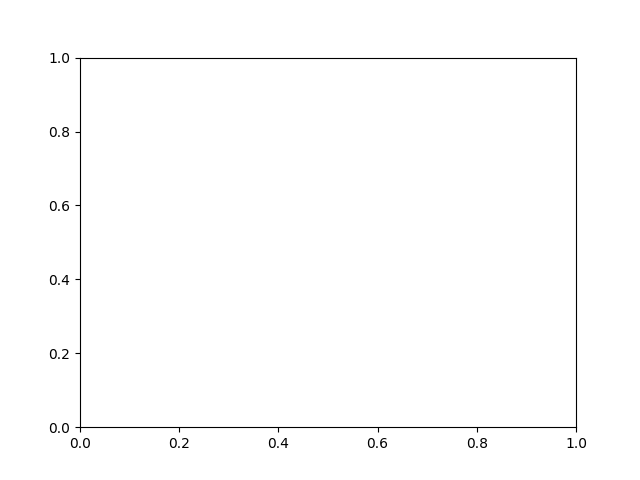

In [12]:
# This code animates the output so you can see what your simulation is doing
fig_ball, axs_ball = plt.subplots()

def draw_ball_frame(i):
    axs_ball.clear()
    axs_ball.set_ylim([0, 5])
    axs_ball.set_xlim([0, 5])
    x = ret_poses[0, i]
    y = ret_poses[1, i]
    ball, = axs_ball.plot(x, y, 'ko')
    ball.set_markersize(7)
    
# We disable repeats for animations because the animation will repeat forever, which can cause issues when re-running a cell.
anim = animation.FuncAnimation(fig_ball, draw_ball_frame, frames=15, interval=100, repeat=False)
plt.show()

In [19]:
grader.check("simulate")

simulate results: All test cases passed!

## Hours and collaborators
Required for every assignment - fill out before you hand-in.

Listing names and websites helps you to document who you worked with and what internet help you received in the case of any plagiarism issues. You should list names of anyone (in class or not) who has substantially helped you with an assignment - or anyone you have *helped*. You do not need to list TAs.

Listing hours helps us track if the assignments are too long.

In [18]:

# List of names (creates a set)
worked_with_names = {""}
# List of URLS F25(creates a set)
websites = {""}
# Approximate number of hours, including lab/in-class time
hours = 1

In [11]:
grader.check("hours_collaborators")

hours_collaborators results: All test cases passed!

### To submit

Double check your plots. 

- Submit this .ipynb file to lecture activity 7 (simulate)

If the Gradescope autograder fails, please check here first for common reasons for it to fail
    https://docs.google.com/presentation/d/1tYa5oycUiG4YhXUq5vHvPOpWJ4k_xUPp2rUNIL7Q9RI/edit?usp=sharing

Failures: None expected